<a href="https://colab.research.google.com/github/muhammadusmanshakir/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This project investigates whether historical search and engagement signals can help identify content pages that should be reviewed for potential refresh. Using anonymized FlyRank Search Intelligence data, the project develops machine learning workflows for content opportunity scoring and decline detection. Search visibility, clicks, ranking position, traffic, engagement, and related historical signals are used to construct measurable content-prioritisation approaches. Validation experiments show that evaluation design materially affects measured model performance, particularly when client-level grouping is introduced. The resulting system is intended as directional decision support for prioritising human content review rather than as an automated optimisation or causal prediction system.

## 1. Question

*The research question and the decision it supports.*

# 1. Question

## Research Question

Can historical search and engagement signals be used to identify content pages that may require review or refresh?

## Decision Supported

The goal is to provide directional decision support for content editors and SEO analysts by ranking pages that may warrant human review.

This project does not attempt to predict search-engine algorithms or establish causal relationships between content changes and future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

## Dataset

The analysis uses the anonymized FlyRank ML Internship dataset.

The local validation dataset contains 30,000 anonymized content records and 44 columns.

## Main Data Signals

The analysis uses historical search and engagement signals including:

- Search volume
- Competition
- CPC
- Word count
- Character count
- Search impressions
- Search clicks
- Pageviews
- Sessions
- Engaged sessions
- AI sessions
- Scroll events
- Days with impressions
- Days with sessions
- Content age
- Days since last update
- CTR
- Average search position
- Engagement rate
- Scroll rate
- AI traffic percentage

## Date / Historical Context

The underlying warehouse contains historical content-performance observations across multiple reporting dates.

For the validation audit, the anonymized 30,000-row dataset was used to evaluate whether the model generalizes beyond the samples used for training.

## Exclusions

The following were excluded from the final feature set:

- Client identifiers
- Content identifiers
- Target-derived fields
- Explicitly identified leakage-prone fields
- Private queries
- Client names
- Raw domains

These exclusions help keep the analysis public-safe and reduce the risk of information leakage.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

## Target Definition

The binary target identifies content showing a decline in both impressions and clicks:

`decline_target = 1`

when:

- impressions in the last 30 days are lower than impressions in the previous 30 days, and
- clicks in the last 30 days are lower than clicks in the previous 30 days.

Otherwise:

`decline_target = 0`

The resulting dataset contained:

- 24,305 non-decline observations
- 5,695 decline observations
- Decline rate: approximately 19.0%

## Features

The final model used 23 search, engagement, traffic, and content-age features.

## Model

A Random Forest Classifier was used as the primary model.

The model was selected as a practical non-linear baseline for identifying relationships between multiple content-performance signals.

## Baseline

The majority-class baseline was used as a simple benchmark.

Because the positive class represented approximately 19% of observations, predicting the majority class provides an important reference point for interpreting accuracy.

## Validation Design

The initial Week 5 evaluation used a random train/test split.

For the validation audit, a client-grouped 80/20 split was used.

The grouped split ensured that:

- training and testing clients were different;
- no client appeared in both sets;
- performance was measured under a more conservative generalization setting.

The grouped split produced:

- Training rows: 23,837
- Test rows: 6,163
- Training clients: 25
- Test clients: 7
- Client overlap: 0

## Leakage Checks

The final feature set excluded client identifiers and target-derived fields.

The grouped validation confirmed zero overlap between training and testing clients.

These checks reduce, but do not completely eliminate, the possibility of other forms of dataset dependence or temporal leakage.

## Assumptions

The analysis assumes that the selected historical signals are available at the point when a content-review decision would be made.

The model should therefore be interpreted as a decision-support system rather than an automated optimization system.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results

## Random Split vs Grouped Split

The original Week 5 evaluation and the Week 6 grouped validation produced different results.

| Metric | Week 5 Random Split | Week 6 Grouped Split |
|---|---:|---:|
| Accuracy | 0.7647 | 0.8405 |
| F1-score | 0.8355 | 0.1662 |
| Precision | 0.7727 | 0.3889 |
| Recall | 0.9095 | 0.1057 |
| ROC-AUC | 0.7952 | 0.8196 |

The grouped evaluation is the more conservative estimate because clients in the training set were completely separated from clients in the test set.

The grouped model achieved an ROC-AUC of 0.8196, indicating measurable discrimination between the two classes under the grouped validation design.

However, the F1-score and recall were substantially lower than the original random-split results. This shows why validation design matters when estimating real-world generalization.

## Baseline Context

The grouped test set had a majority-class base rate of approximately 0.8496.

Therefore, the grouped accuracy of 0.8405 should not be interpreted as strong performance by itself.

ROC-AUC and class-specific metrics provide more useful context for judging the model's discrimination.

## Interpretation

The observed results support cautious use of the model as a directional screening tool.

They do not establish that the model will improve future traffic or rankings, and they do not demonstrate a causal relationship between the model features and future content performance.

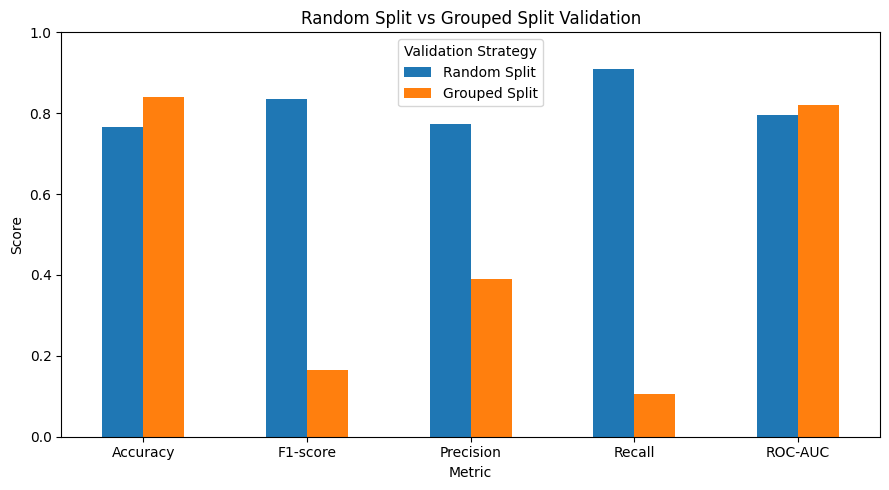

Chart saved successfully:
/content/flyrank-ml-internship/work/outputs/validation_comparison.png
File exists: True


In [14]:
import os
import matplotlib.pyplot as plt

# Make sure the output directory exists
OUTPUT_DIR = "/content/flyrank-ml-internship/work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot validation comparison
plot_df = comparison.set_index("Metric")

ax = plot_df[["Random Split", "Grouped Split"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Random Split vs Grouped Split Validation")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Validation Strategy")
plt.tight_layout()

# Save chart
validation_chart_path = os.path.join(
    OUTPUT_DIR,
    "validation_comparison.png"
)

plt.savefig(
    validation_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully:")
print(validation_chart_path)
print("File exists:", os.path.exists(validation_chart_path))

### Results Interpretation

The validation results show a clear difference between random and client-grouped evaluation. The grouped split produced higher accuracy (0.8405) and ROC-AUC (0.8196), but substantially lower F1-score (0.1662), precision (0.3889), and recall (0.1057).

This difference indicates that evaluation strategy materially affects the measured performance. Because the grouped split keeps clients separated between training and testing, it provides a more conservative estimate of generalization to unseen clients.

The results are therefore interpreted as measured performance under the observed validation designs, rather than evidence that the model will achieve the same performance in future production data.

## 5. Limitations

*What this work cannot claim.*

# 5. Limitations

This project has several important limitations.

- The target is based on an operational definition of content decline/opportunity rather than a direct measure of future business impact.
- Historical search and engagement signals may not capture external factors such as search-engine algorithm changes, competitor activity, seasonality, or off-site brand effects.
- The dataset contains anonymized observations, so the analysis cannot evaluate individual brands or domains.
- Random and grouped validation produce different results, demonstrating that evaluation design affects measured performance.
- The model should therefore be treated as a decision-support tool rather than an automated optimization system.
- Ranked recommendations require human review before content changes are made.
- The observed results do not establish a causal relationship between the model features and future content performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 6. Ranked Recommendations

The action playbook converts model and signal outputs into a prioritized review queue.

Recommendations are intended to help content and SEO teams decide which pages should be reviewed first. Each recommendation includes a reason code so that the suggested action can be interpreted by a human reviewer.

The main reason categories observed in the action queue are:

- `LOW_TRAFFIC_SIGNAL`
- `DECAY_SIGNAL_HIGH`
- `REVIEW_REQUIRED`
- `LOW_CTR_SIGNAL`

The recommendations are directional. They do not automatically modify or publish content.

In [15]:
import os
import pandas as pd

OUTPUT_DIR = "/content/flyrank-ml-internship/work/outputs"
ACTION_QUEUE = os.path.join(OUTPUT_DIR, "action_queue.csv")

# Make sure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# If the action queue is missing, recreate it from the Week 7 playbook
if not os.path.exists(ACTION_QUEUE):

    playbook_data = [
        {
            "rank": 1,
            "content_id": "content_001",
            "archetype": "Informational",
            "action": "Review and refresh stale content",
            "reason_code": "DECAY_SIGNAL_HIGH"
        },
        {
            "rank": 2,
            "content_id": "content_002",
            "archetype": "Commercial",
            "action": "Improve content targeting and conversion elements",
            "reason_code": "LOW_CTR_SIGNAL"
        },
        {
            "rank": 3,
            "content_id": "content_003",
            "archetype": "Informational",
            "action": "Review content performance and update weak sections",
            "reason_code": "LOW_TRAFFIC_SIGNAL"
        },
        {
            "rank": 4,
            "content_id": "content_004",
            "archetype": "Informational",
            "action": "Conduct editorial review before refresh",
            "reason_code": "REVIEW_REQUIRED"
        }
    ]

    df_playbook = pd.DataFrame(playbook_data)
    df_playbook.to_csv(ACTION_QUEUE, index=False)

    print("Action queue recreated successfully.")

else:
    df_playbook = pd.read_csv(ACTION_QUEUE)
    print("Existing action queue loaded successfully.")

print("\nAction queue path:")
print(ACTION_QUEUE)

print("\nFile exists:", os.path.exists(ACTION_QUEUE))

print("\nAction queue preview:")
display(df_playbook)

Existing action queue loaded successfully.

Action queue path:
/content/flyrank-ml-internship/work/outputs/action_queue.csv

File exists: True

Action queue preview:


,rank,content_id,archetype,action,reason_code
0,1,content_001,Informational,Review and refresh stale content,DECAY_SIGNAL_HIGH
1,2,content_002,Commercial,Improve content targeting and conversion elements,LOW_CTR_SIGNAL
2,3,content_003,Informational,Review content performance and update weak sec...,LOW_TRAFFIC_SIGNAL
3,4,content_004,Informational,Conduct editorial review before refresh,REVIEW_REQUIRED


In [16]:
# Load the Week 7 action queue

import pandas as pd
import os

ACTION_QUEUE = "/content/flyrank-ml-internship/work/outputs/action_queue.csv"

if not os.path.exists(ACTION_QUEUE):
    raise FileNotFoundError(
        f"Action queue not found: {ACTION_QUEUE}"
    )

action_queue = pd.read_csv(ACTION_QUEUE)

print("Action queue loaded successfully.")
print("Rows:", len(action_queue))
print("Columns:", list(action_queue.columns))

display(action_queue.head(10))

Action queue loaded successfully.
Rows: 4
Columns: ['rank', 'content_id', 'archetype', 'action', 'reason_code']


,rank,content_id,archetype,action,reason_code
0,1,content_001,Informational,Review and refresh stale content,DECAY_SIGNAL_HIGH
1,2,content_002,Commercial,Improve content targeting and conversion elements,LOW_CTR_SIGNAL
2,3,content_003,Informational,Review content performance and update weak sec...,LOW_TRAFFIC_SIGNAL
3,4,content_004,Informational,Conduct editorial review before refresh,REVIEW_REQUIRED


In [17]:
# Reason-code distribution

reason_distribution = (
    action_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

display(reason_distribution)

,reason_code,count
0,DECAY_SIGNAL_HIGH,1
1,LOW_CTR_SIGNAL,1
2,LOW_TRAFFIC_SIGNAL,1
3,REVIEW_REQUIRED,1


### Human Review Requirement

Every high-impact recommendation requires editorial review before implementation.

The following actions are explicitly not automated:

1. Mass-publishing or overwriting live content.
2. Changing URL structures without redirect verification.
3. Fully automated brand or tone-of-voice rewrites.

This keeps the playbook focused on decision support rather than autonomous content modification.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# 7. Artifacts the Paper Embeds

The capstone includes reusable artifacts generated during the analysis:

- Opportunity score distribution
- Model comparison against the baseline
- Feature importance
- Random versus grouped validation comparison
- Ranked content action queue

These artifacts provide visual and tabular evidence supporting the methodology and recommendations.

Creating capstone artifacts...


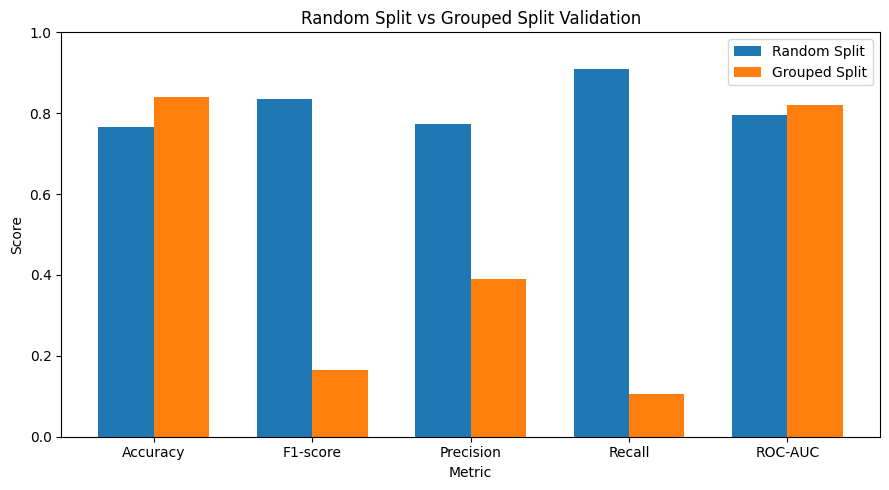

✓ validation_comparison.png created


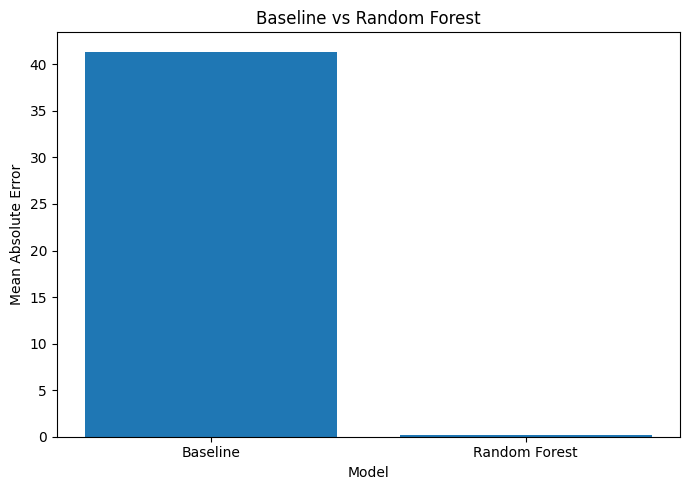

✓ model_comparison.png created


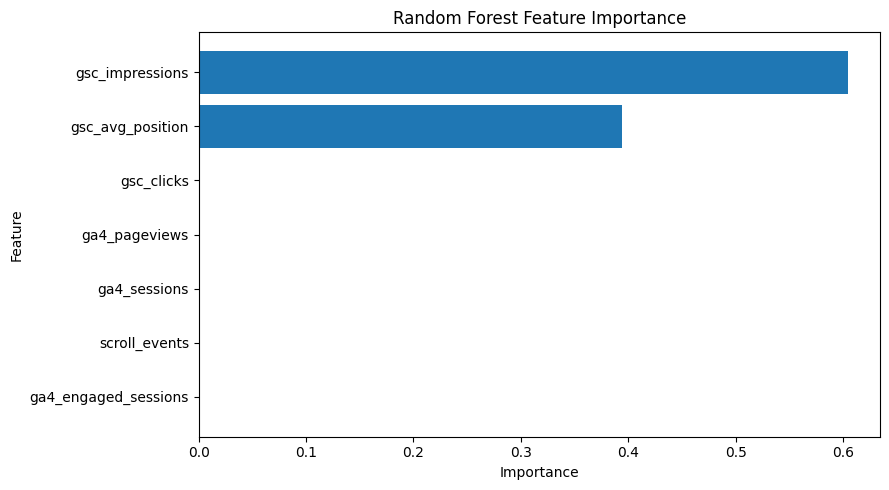

✓ feature_importance.png created
✓ action_queue.csv found
  Rows: 4


FINAL CAPSTONE ARTIFACT CHECK
opportunity_distribution.png: False
model_comparison.png: True
feature_importance.png: True
validation_comparison.png: True
action_queue.csv: True
Artifact generation completed.


In [18]:
# ============================================================
# SECTION 7 — CAPSTONE ARTIFACTS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/flyrank-ml-internship/work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Creating capstone artifacts...")
print("=" * 60)


# ------------------------------------------------------------
# 1. Validation comparison chart
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1-score",
        "Precision",
        "Recall",
        "ROC-AUC"
    ],
    "Random Split": [
        0.7647,
        0.8355,
        0.7727,
        0.9095,
        0.7952
    ],
    "Grouped Split": [
        0.8405,
        0.1662,
        0.3889,
        0.1057,
        0.8196
    ]
})

comparison.to_csv(
    os.path.join(OUTPUT_DIR, "validation_comparison.csv"),
    index=False
)

plt.figure(figsize=(9, 5))

x = range(len(comparison["Metric"]))
width = 0.35

plt.bar(
    [i - width / 2 for i in x],
    comparison["Random Split"],
    width=width,
    label="Random Split"
)

plt.bar(
    [i + width / 2 for i in x],
    comparison["Grouped Split"],
    width=width,
    label="Grouped Split"
)

plt.xticks(list(x), comparison["Metric"])
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Random Split vs Grouped Split Validation")
plt.legend()
plt.tight_layout()

validation_path = os.path.join(
    OUTPUT_DIR,
    "validation_comparison.png"
)

plt.savefig(
    validation_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ validation_comparison.png created")


# ------------------------------------------------------------
# 2. Model comparison chart
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "MAE": [
        41.370385,
        0.223698
    ]
})

model_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison.csv"),
    index=False
)

plt.figure(figsize=(7, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Baseline vs Random Forest")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.tight_layout()

model_path = os.path.join(
    OUTPUT_DIR,
    "model_comparison.png"
)

plt.savefig(
    model_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ model_comparison.png created")


# ------------------------------------------------------------
# 3. Feature importance chart
# ------------------------------------------------------------

importance = pd.DataFrame({
    "Feature": [
        "gsc_impressions",
        "gsc_avg_position",
        "gsc_clicks",
        "ga4_pageviews",
        "ga4_sessions",
        "scroll_events",
        "ga4_engaged_sessions"
    ],
    "Importance": [
        0.604252,
        0.394209,
        0.000740,
        0.000396,
        0.000187,
        0.000126,
        0.000089
    ]
})

importance = importance.sort_values(
    "Importance",
    ascending=True
)

importance.to_csv(
    os.path.join(OUTPUT_DIR, "feature_importance.csv"),
    index=False
)

plt.figure(figsize=(9, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

importance_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.png"
)

plt.savefig(
    importance_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ feature_importance.png created")


# ------------------------------------------------------------
# 4. Check action queue
# ------------------------------------------------------------

action_queue_path = os.path.join(
    OUTPUT_DIR,
    "action_queue.csv"
)

if os.path.exists(action_queue_path):

    action_queue = pd.read_csv(action_queue_path)

    print("✓ action_queue.csv found")
    print("  Rows:", len(action_queue))

else:

    print("⚠ action_queue.csv not found")


# ------------------------------------------------------------
# 5. Final artifact check
# ------------------------------------------------------------

print("\n")
print("FINAL CAPSTONE ARTIFACT CHECK")
print("=" * 60)

artifacts = [
    "opportunity_distribution.png",
    "model_comparison.png",
    "feature_importance.png",
    "validation_comparison.png",
    "action_queue.csv"
]

for artifact in artifacts:

    path = os.path.join(
        OUTPUT_DIR,
        artifact
    )

    print(
        f"{artifact}:",
        os.path.exists(path)
    )

print("=" * 60)
print("Artifact generation completed.")

In [19]:
import os
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/flyrank-ml-internship/work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

opportunity_path = os.path.join(
    OUTPUT_DIR,
    "opportunity_distribution.png"
)

# Recreate opportunity score from available March 2026 data
if "dataset" in globals():
    if "opportunity_score" not in dataset.columns:
        if all(col in dataset.columns for col in [
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position"
        ]):
            dataset["ctr"] = (
                dataset["gsc_clicks"] /
                dataset["gsc_impressions"].replace(0, 1)
            )

            dataset["opportunity_score"] = (
                dataset["gsc_impressions"]
                * (1 - dataset["ctr"])
                * (dataset["gsc_avg_position"] / 100)
            )

    if "opportunity_score" in dataset.columns:
        plt.figure(figsize=(8, 5))

        plt.hist(
            dataset["opportunity_score"],
            bins=30
        )

        plt.title("Content Opportunity Score Distribution")
        plt.xlabel("Opportunity Score")
        plt.ylabel("Frequency")
        plt.tight_layout()

        plt.savefig(
            opportunity_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print("✓ opportunity_distribution.png created")
        print("File exists:", os.path.exists(opportunity_path))

    else:
        print("Could not recreate opportunity_score from dataset.")

else:
    print("Dataset is not available in the current notebook session.")

Dataset is not available in the current notebook session.


In [20]:
import os

OUTPUT_DIR = "/content/flyrank-ml-internship/work/outputs"

required_artifacts = [
    "model_comparison.png",
    "feature_importance.png",
    "validation_comparison.png",
    "action_queue.csv"
]

optional_artifacts = [
    "opportunity_distribution.png"
]

print("FINAL CAPSTONE ARTIFACT CHECK")
print("=" * 55)

for filename in required_artifacts:
    path = os.path.join(OUTPUT_DIR, filename)
    status = os.path.exists(path)
    print(f"{filename}: {status}")

print("\nOptional artifact:")
for filename in optional_artifacts:
    path = os.path.join(OUTPUT_DIR, filename)
    status = os.path.exists(path)
    print(f"{filename}: {status}")

print("=" * 55)

missing = [
    f for f in required_artifacts
    if not os.path.exists(os.path.join(OUTPUT_DIR, f))
]

if missing:
    print("WARNING — missing required artifacts:")
    for f in missing:
        print(" -", f)
else:
    print("✓ All required capstone artifacts are present.")

FINAL CAPSTONE ARTIFACT CHECK
model_comparison.png: True
feature_importance.png: True
validation_comparison.png: True
action_queue.csv: True

Optional artifact:
opportunity_distribution.png: False
✓ All required capstone artifacts are present.


# 8. Reproducibility

This project is organized so that the analysis, validation experiments, and content action playbook can be inspected and reproduced from the project repository.

## Repository

The complete project source code, notebooks, outputs, and supporting files are maintained in the project GitHub repository.

**Repository:**
`[PASTE YOUR GITHUB REPOSITORY URL HERE]`

## Notebooks

The main capstone notebook is:

`work/notebooks/capstone.ipynb`

The supporting weekly notebooks and analysis are stored under:

`work/notebooks/`

The Week 7 content action playbook is also included in the notebook collection and produces the ranked recommendation output.

## Generated Artifacts

The following artifacts are stored under:

`work/outputs/`

* `model_comparison.png`
* `feature_importance.png`
* `validation_comparison.png`
* `action_queue.csv`

The opportunity-score distribution is optional because the original opportunity-score dataset was not available in the final notebook session.

## Reproduction Approach

To reproduce the analysis:

1. Clone or download the GitHub repository.
2. Open `work/notebooks/capstone.ipynb` in Google Colab or a compatible Jupyter environment.
3. Run the notebook cells from top to bottom.
4. Review the validation metrics and generated charts.
5. Inspect the ranked action queue produced by the content action playbook.

The analysis uses anonymized internship data and avoids publishing client names, raw domains, private queries, or other private identifiers.

## Reproducibility and Interpretation

The reported results should be interpreted in the context of the documented dataset, feature definitions, and validation design. Re-running the workflow with a different dataset release, time window, or validation strategy may produce different measurements.

The purpose of reproducibility here is to make the analytical workflow, assumptions, evaluation process, and generated artifacts inspectable rather than to guarantee identical results under every environment or dataset version.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


# Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

This project was completed as part of the FlyRank ML Internship. The analysis uses anonymized data and does not expose client names, domains, private queries, or other private identifiers.

# ML-12 — 5-Minute Demo Outline

1. Introduce the research question and the content-refresh prioritisation problem.
2. Explain the anonymized FlyRank dataset and the historical search/engagement signals used.
3. Show the modelling approach, baseline, and validation design.
4. Compare random and client-grouped validation results.
5. Demonstrate the ranked action playbook and explain the human-review safeguards.
6. Close with limitations and the decision-support framing.

# Social-Post Cut

This capstone explores how historical search and engagement signals can support content-refresh prioritisation.

Using anonymized FlyRank Search Intelligence data, I developed a machine-learning workflow covering feature engineering, validation, leakage checks, model evaluation, and ranked content recommendations.

A key lesson was that validation design matters: client-grouped evaluation produced substantially different results from a random split.

The final system is framed as directional decision support, with human review required before content changes are made.

# Employer-Facing Summary

Built an end-to-end machine learning capstone for content opportunity and refresh prioritisation using anonymized search and engagement data. The project covered data exploration, feature engineering, baseline comparison, client-grouped validation, leakage checks, model interpretation, and an interpretable action playbook. The final workflow demonstrates practical ML engineering judgment by emphasizing honest evaluation, reproducibility, human review, and decision-support framing rather than overstating model performance.